# Incomplete AwA2 — results

Intervention curves and accuracy tables for the 3-seed runs (seeds 0/10/20) of each
model on the incomplete AwA2 concept set (`awa2_incomplete_local_custom_1`, 9 of 85
concepts kept, 50 classes). Run from the repository root.

In [1]:
import os

## Intervention curves

Reads `intervention_log.txt` from the 3 seed runs of each model under
`experiments/<model_type>/AwA2/` and plots task accuracy vs. number of concepts
intervened on: line = seed mean, shaded band = spread across seeds.

SCBM                           seeds [0, 10, 20]  curves (3, 10)  [9 concepts, 50 classes, awa2_incomplete_local_custom_1]
Res-SCBM                       seeds [0, 10, 20]  curves (3, 10)  [9 concepts, 50 classes, awa2_incomplete_local_custom_1]
Res-SCBM + $L_{int}$           seeds [0, 10, 20]  curves (3, 10)  [9 concepts, 50 classes, awa2_incomplete_local_custom_1]
Hard CBM                       seeds [0, 10, 20]  curves (3, 10)  [9 concepts, 50 classes, awa2_incomplete_local_custom_1]
CEM (RandInt $p_{int}$=0.25)   seeds [0, 10, 20]  curves (3, 10)  [9 concepts, 50 classes, awa2_incomplete_local_custom_1]
Linear head (GT concepts)      seeds [0, 10, 20]  test acc [76.22, 76.22, 76.17]


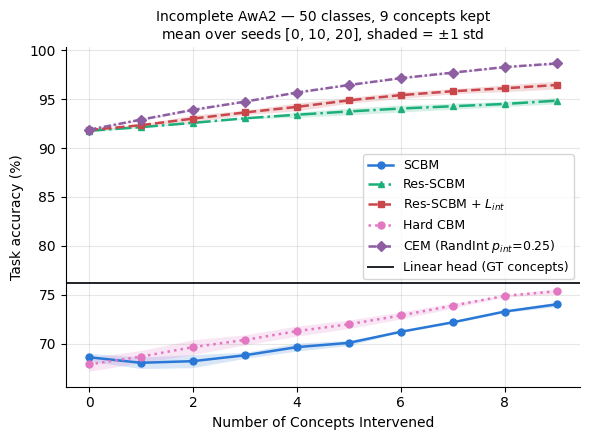

In [2]:
import re
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (label, model_type, run_dir_glob) -- one entry per model, each glob matching that
# model's 3 seed runs under experiments/<model_type>/AwA2/. The globs are anchored on the
# save_name prefix so they cannot collide: the plain Res-SCBM runs are
# "incomplete_awa2_emp_perc_residuals_20_2026-*", the L_int ones carry the extra
# "L_int_extension_loss_weight_1" tag. The older single-seed runs live in AwA2_old/ and
# are deliberately not matched.
AWA2_MODELS = [
    ("SCBM",                 "scbm",          "incomplete_awa2_2026-*"),
    ("Res-SCBM",             "scbm_residual", "incomplete_awa2_emp_perc_residuals_20_2026-*"),
    ("Res-SCBM + $L_{int}$", "scbm_residual",
     "incomplete_awa2_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-*"),
    ("Hard CBM",             "cbm",           "hard_cbm_incomplete_awa2_2026-*"),
    # CEM is the only model here trained *on* interventions (RandInt, model.p_int=0.25),
    # so its slope with concept count is not a like-for-like comparison against the rest.
    ("CEM (RandInt $p_{int}$=0.25)", "cbm",   "cem_p_int_0.25_incomplete_awa2_2026-*"),
]

COLORS = {
    "SCBM": "#2a78d6",
    "Res-SCBM": "#1baf7a",
    "Res-SCBM + $L_{int}$": "#c9464b",
    "Hard CBM": "#e377c2",
    "CEM (RandInt $p_{int}$=0.25)": "#8e5ea2",
}
MARKERS = {"SCBM": "o", "Res-SCBM": "^", "Res-SCBM + $L_{int}$": "s", "Hard CBM": "o",
           "CEM (RandInt $p_{int}$=0.25)": "D"}
LINESTYLES = {"SCBM": "-", "Res-SCBM": "-.", "Res-SCBM + $L_{int}$": "--", "Hard CBM": ":",
              "CEM (RandInt $p_{int}$=0.25)": (0, (3, 1, 1, 1))}

# Ground-truth reference: nn.Linear(num_concepts, num_classes) trained by eval_datasets.py
# on the *true* labels of the kept concepts of the same split -- the accuracy the kept
# concepts alone support. It has no concept predictions and hence no intervention sweep:
# one test accuracy per seed, drawn as a flat line. The seedless complete_* run is not matched.
GT_LABEL = "Linear head (GT concepts)"
GT_GLOB = "awa2_incomplete_local_custom_1_2026-*_seed_*"
GT_COLOR = "#1f2328"

EXPECTED_SEEDS = {0, 10, 20}
BAND = "std"  # "std" -> mean +/- 1 std across seeds; "minmax" -> full seed range


def read_run_config(run_path):
    """First line of log.txt is the full config dict."""
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        return ast.literal_eval(f.readline().strip())


def parse_intervention_log(log_txt_path):
    """Return (xs, rows) with rows[i] a {metric: value} dict for xs[i] concepts intervened.

    Keyed by concept count so that a log containing a partial sweep followed by a
    re-run keeps the *last* value written.
    """
    curve = {}
    with open(log_txt_path, "r") as f:
        for line in f:
            m = re.search(r"Intervention on (\d+) concepts", line)
            if not m or "y_accuracy" not in line:
                continue
            curve[int(m.group(1))] = {
                k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", line)
            }
    xs = sorted(curve)
    return xs, [curve[x] for x in xs]


def collect_model(label, model_type, run_glob, dataset="AwA2", metric="y_accuracy"):
    """Stack one model's per-seed intervention curves into an (n_seeds, n_points) array."""
    run_paths = sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob)))
    seeds, curves, run_dirs, xs_ref, shapes = [], [], [], None, set()
    for run_path in run_paths:
        log_txt = os.path.join(run_path, "intervention_log.txt")
        if not os.path.exists(log_txt):
            continue
        cfg = read_run_config(run_path)
        xs, rows = parse_intervention_log(log_txt)
        if xs_ref is None:
            xs_ref = xs
        assert xs == xs_ref, f"{run_path}: intervention grid differs from the other seeds"
        # Seeds are only comparable if they were trained on the same incomplete split.
        shapes.add((cfg["data"]["num_classes"], cfg["data"]["num_concepts"],
                    cfg["data"]["pkl_file_dir"].rstrip("/")))
        seeds.append(cfg["seed"])
        curves.append([r[metric] * 100 for r in rows])
        run_dirs.append(os.path.basename(run_path))
    assert set(seeds) == EXPECTED_SEEDS, \
        f"{label}: found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    assert len(shapes) == 1, f"{label}: seeds disagree on classes/concepts/split: {shapes}"
    return {"label": label, "model_type": model_type, "seeds": sorted(seeds),
            "run_dirs": run_dirs, "shape": shapes.pop(),
            "x": np.array(xs_ref), "y": np.array(curves)}


def collect_linear_head(run_glob, dataset, shape):
    """Per-seed test target accuracy (%) of the ground-truth-concept linear head.

    eval_datasets.py writes a slimmer log than train.py: line 1 is a flat info dict (no
    nested "data", no "seed"), the seed is only in the folder name, and the result is a
    single "Final Test Accuracy" line. `shape` is the (classes, concepts, split) of the
    models it is compared against.
    """
    seeds, accs, run_dirs = [], [], []
    for run_path in sorted(glob.glob(os.path.join("experiments", "linear_head", dataset, run_glob))):
        info = read_run_config(run_path)
        assert info["model_type"] == "linear_head" and not info["use_residuals_from_data"], run_path
        run_shape = (info["num_classes"], info["num_concepts"], info["pkl_file_dir"].rstrip("/"))
        assert run_shape == shape, f"{run_path}: trained on {run_shape}, models are on {shape}"
        seeds.append(int(re.search(r"_seed_(\d+)_", os.path.basename(run_path)).group(1)))
        found = re.findall(r"Final Test Accuracy:\s*([0-9.]+)",
                           open(os.path.join(run_path, "log.txt")).read())
        assert len(found) == 1, f"{run_path}: expected 1 'Final Test Accuracy', found {len(found)}"
        accs.append(float(found[0]) * 100)
        run_dirs.append(os.path.basename(run_path))
    assert sorted(seeds) == sorted(EXPECTED_SEEDS), \
        f"{GT_LABEL}: found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    return {"label": GT_LABEL, "seeds": sorted(seeds), "run_dirs": run_dirs, "y": np.array(accs)}


def gt_band(gt):
    """(mean, lo, hi) of the linear head's seed accuracies, same BAND rule as the curves."""
    mean = gt["y"].mean()
    if BAND == "std":
        sd = gt["y"].std(ddof=1)
        return mean, mean - sd, mean + sd
    return mean, gt["y"].min(), gt["y"].max()


metric = "y_accuracy"
models = [collect_model(*m, metric=metric) for m in AWA2_MODELS]
for m in models:
    n_classes, n_concepts, pkl_dir = m["shape"]
    print(f"{m['label']:<30} seeds {m['seeds']}  curves {m['y'].shape}  "
          f"[{n_concepts} concepts, {n_classes} classes, {pkl_dir}]")
# One x-axis only makes sense if every model saw the same concept set.
assert len({m["shape"] for m in models}) == 1, "models are not on the same AwA2 setup"
assert all((m["x"] == models[0]["x"]).all() for m in models), "models differ in x grid"

gt = collect_linear_head(GT_GLOB, "AwA2", models[0]["shape"])
print(f"{GT_LABEL:<30} seeds {gt['seeds']}  test acc {np.round(gt['y'], 2).tolist()}")

fig, ax = plt.subplots(figsize=(6.0, 4.5))
for m in models:
    mean = m["y"].mean(axis=0)
    if BAND == "std":
        band_lo, band_hi = mean - m["y"].std(axis=0, ddof=1), mean + m["y"].std(axis=0, ddof=1)
    else:
        band_lo, band_hi = m["y"].min(axis=0), m["y"].max(axis=0)
    color = COLORS[m["label"]]
    ax.fill_between(m["x"], band_lo, band_hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(m["x"], mean, marker=MARKERS[m["label"]], ms=5, lw=1.8,
            linestyle=LINESTYLES[m["label"]], color=color, label=m["label"])

gt_mean, gt_lo, gt_hi = gt_band(gt)
ax.axhspan(gt_lo, gt_hi, color=GT_COLOR, alpha=0.12, linewidth=0)
ax.axhline(gt_mean, color=GT_COLOR, lw=1.4, label=GT_LABEL)

n_classes, n_concepts, _ = models[0]["shape"]
ax.set_xlabel("Number of Concepts Intervened")
ax.set_ylabel("Task accuracy (%)")
ax.set_title(f"Incomplete AwA2 — {n_classes} classes, {n_concepts} concepts kept\n"
             f"mean over seeds {models[0]['seeds']}, shaded = "
             + ("$\\pm$1 std" if BAND == "std" else "min-max range"), fontsize=10)
ax.grid(True, alpha=0.3)
# Center right: the curves split into a ~92-98% and a ~68-76% cluster with the ground-truth
# line at ~76%, so the gap between them is the only spot the legend covers nothing.
ax.legend(fontsize=9, loc="center right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join("plots", "awa2_incomplete_intervention_curves.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## Test accuracy table

In [3]:
# Test-set concept / target accuracy, mean +/- std over the 3 seeds of each model.
#
# Source is the single "Test:" line of each run's log.txt (the best-validation checkpoint
# evaluated on the test split), NOT the 0-intervention row of intervention_log.txt: the
# two differ slightly because the intervention sweep re-samples the concept logits.
# Reuses AWA2_MODELS / read_run_config / EXPECTED_SEEDS / gt from the intervention-curve cell.
# The ground-truth linear head is appended as a separate reference row: it has no concept
# accuracy ("—") and is excluded from the best / runner-up marking.

TABLE_ORDER = [
    "Hard CBM",
    "CEM (RandInt $p_{int}$=0.25)",
    "SCBM",
    "Res-SCBM",
    "Res-SCBM + $L_{int}$",
]
TABLE_NAMES = {  # plain names for the table, without the plot's mathtext
    "CEM (RandInt $p_{int}$=0.25)": "CEM (RandInt p_int=0.25)",
    "Res-SCBM + $L_{int}$": "Res-SCBM + L_int",
}
METRICS = [("c_accuracy", "Concept Accuracy"), ("y_accuracy", "Target Accuracy")]


def parse_test_line(run_path):
    """Parse the run's single 'Test:' line from log.txt into a {metric: value} dict."""
    test_lines = [l for l in open(os.path.join(run_path, "log.txt")) if l.startswith("Test:")]
    assert len(test_lines) == 1, f"{run_path}: expected 1 'Test:' line, found {len(test_lines)}"
    return {k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", test_lines[0])}


def collect_test_metrics(label, model_type, run_glob, dataset="AwA2"):
    """Per-seed test metrics for one model, as {metric: np.array of len n_seeds}."""
    seeds, rows = [], []
    for run_path in sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob))):
        seeds.append(read_run_config(run_path)["seed"])
        rows.append(parse_test_line(run_path))
    assert set(seeds) == EXPECTED_SEEDS, \
        f"{label}: found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    return {m: np.array([r[m] * 100 for r in rows]) for m, _ in METRICS}


specs = {label: (label, mt, g) for label, mt, g in AWA2_MODELS}
stats = {label: collect_test_metrics(*specs[label]) for label in TABLE_ORDER}

table = pd.DataFrame(
    {col: [f"{stats[l][m].mean():.2f} ± {stats[l][m].std(ddof=1):.2f}" for l in TABLE_ORDER]
     for m, col in METRICS},
    index=[TABLE_NAMES.get(l, l) for l in TABLE_ORDER],
)
table.loc[GT_LABEL] = [f"{gt['y'].mean():.2f} ± {gt['y'].std(ddof=1):.2f}"
                       if m == "y_accuracy" else "—" for m, _ in METRICS]
table.index.name = "Method"
display(table)

# LaTeX version: best in bold, runner-up underlined, as in the SCBM paper's table.
latex_rows = []
for label in TABLE_ORDER:
    cells = []
    for m, _ in METRICS:
        means = np.array([stats[l][m].mean() for l in TABLE_ORDER])
        rank = means.argsort()[::-1]          # descending; higher accuracy is better
        best, second = TABLE_ORDER[rank[0]], TABLE_ORDER[rank[1]]
        cell = f"{stats[label][m].mean():.2f} $\\pm$ {stats[label][m].std(ddof=1):.2f}"
        if label == best:
            cell = f"\\textbf{{{cell}}}"
        elif label == second:
            cell = f"\\underline{{{cell}}}"
        cells.append(cell)
    latex_rows.append(f"{TABLE_NAMES.get(label, label)} & " + " & ".join(cells) + r" \\")
gt_cells = [f"{gt['y'].mean():.2f} $\\pm$ {gt['y'].std(ddof=1):.2f}"
            if m == "y_accuracy" else "--" for m, _ in METRICS]

print("\n% Incomplete AwA2 (awa2_incomplete_local_custom_1), test split, mean $\\pm$ std over 3 seeds")
print(r"\begin{tabular}{lcc}")
print(r"\toprule")
print(r"Method & Concept Accuracy & Target Accuracy \\")
print(r"\midrule")
print("\n".join(latex_rows))
print(r"\midrule")
print(f"{GT_LABEL} & " + " & ".join(gt_cells) + r" \\")
print(r"\bottomrule")
print(r"\end{tabular}")

,Concept Accuracy,Target Accuracy
Method,,
Hard CBM,96.10 ± 0.00,68.20 ± 0.87
CEM (RandInt p_int=0.25),96.57 ± 0.15,91.87 ± 0.06
SCBM,96.03 ± 0.06,68.43 ± 0.31
Res-SCBM,96.07 ± 0.06,91.87 ± 0.06
Res-SCBM + L_int,96.10 ± 0.00,91.77 ± 0.12
Linear head (GT concepts),—,76.20 ± 0.03



% Incomplete AwA2 (awa2_incomplete_local_custom_1), test split, mean $\pm$ std over 3 seeds
\begin{tabular}{lcc}
\toprule
Method & Concept Accuracy & Target Accuracy \\
\midrule
Hard CBM & 96.10 $\pm$ 0.00 & 68.20 $\pm$ 0.87 \\
CEM (RandInt p_int=0.25) & \textbf{96.57 $\pm$ 0.15} & \underline{91.87 $\pm$ 0.06} \\
SCBM & 96.03 $\pm$ 0.06 & 68.43 $\pm$ 0.31 \\
Res-SCBM & 96.07 $\pm$ 0.06 & \textbf{91.87 $\pm$ 0.06} \\
Res-SCBM + L_int & \underline{96.10 $\pm$ 0.00} & 91.77 $\pm$ 0.12 \\
\midrule
Linear head (GT concepts) & -- & 76.20 $\pm$ 0.03 \\
\bottomrule
\end{tabular}


## Target accuracy under intervention

In [4]:
# Target accuracy at selected points along the intervention sweep -- the tabular form of
# the curve above. Mean +/- std over the 3 seeds, read from the same intervention_log.txt
# curves (`models`), so these numbers match the plot exactly (and sit a few tenths off the
# "Test:" row of the table above, which re-uses a different concept-logit sample).
# Reuses `models` / `gt` from the intervention-curve cell and TABLE_ORDER / TABLE_NAMES from
# the test-accuracy cell. The ground-truth linear head is the same value in every column
# (it takes no predicted concepts, so there is nothing to intervene on) and is kept out of
# the best / runner-up marking.

INTERVENTION_POINTS = [0, 2, 4, 6, 8, 9]  # all 9 kept concepts is the full sweep

by_label = {m["label"]: m for m in models}
x_grid = list(models[0]["x"])
missing = [k for k in INTERVENTION_POINTS if k not in x_grid]
assert not missing, f"no sweep point for {missing}; grid is {x_grid[0]}..{x_grid[-1]}"
cols = [x_grid.index(k) for k in INTERVENTION_POINTS]

# (n_methods, n_points) mean/std of target accuracy, rows in TABLE_ORDER
means = np.array([by_label[l]["y"][:, cols].mean(axis=0) for l in TABLE_ORDER])
stds = np.array([by_label[l]["y"][:, cols].std(axis=0, ddof=1) for l in TABLE_ORDER])

int_table = pd.DataFrame(
    [[f"{mu:.2f} ± {sd:.2f}" for mu, sd in zip(mu_row, sd_row)]
     for mu_row, sd_row in zip(means, stds)],
    index=[TABLE_NAMES.get(l, l) for l in TABLE_ORDER],
    columns=[f"{k} int." for k in INTERVENTION_POINTS],
)
int_table.loc[GT_LABEL] = [f"{gt['y'].mean():.2f} ± {gt['y'].std(ddof=1):.2f}"] * len(INTERVENTION_POINTS)
int_table.index.name = "Method"
print(f"Target accuracy (%) vs. number of concepts intervened — "
      f"mean ± std over seeds {models[0]['seeds']}")
display(int_table)

# LaTeX version: best per column in bold, runner-up underlined.
rank = (-means).argsort(axis=0)  # descending down each column; higher accuracy is better
latex_rows = []
for i, label in enumerate(TABLE_ORDER):
    cells = []
    for j in range(len(INTERVENTION_POINTS)):
        cell = f"{means[i, j]:.2f} $\\pm$ {stds[i, j]:.2f}"
        if i == rank[0, j]:
            cell = f"\\textbf{{{cell}}}"
        elif i == rank[1, j]:
            cell = f"\\underline{{{cell}}}"
        cells.append(cell)
    latex_rows.append(f"{TABLE_NAMES.get(label, label)} & " + " & ".join(cells) + r" \\")
gt_cell = f"{gt['y'].mean():.2f} $\\pm$ {gt['y'].std(ddof=1):.2f}"

print("\n% Incomplete AwA2 (awa2_incomplete_local_custom_1), test split, target accuracy under intervention")
print(r"\begin{tabular}{l" + "c" * len(INTERVENTION_POINTS) + "}")
print(r"\toprule")
print(r"& \multicolumn{%d}{c}{Number of concepts intervened} \\" % len(INTERVENTION_POINTS))
print(r"\cmidrule(lr){2-%d}" % (len(INTERVENTION_POINTS) + 1))
print("Method & " + " & ".join(str(k) for k in INTERVENTION_POINTS) + r" \\")
print(r"\midrule")
print("\n".join(latex_rows))
print(r"\midrule")
print(f"{GT_LABEL} & " + " & ".join([gt_cell] * len(INTERVENTION_POINTS)) + r" \\")
print(r"\bottomrule")
print(r"\end{tabular}")

Target accuracy (%) vs. number of concepts intervened — mean ± std over seeds [0, 10, 20]


,0 int.,2 int.,4 int.,6 int.,8 int.,9 int.
Method,,,,,,
Hard CBM,67.90 ± 0.70,69.67 ± 0.75,71.30 ± 0.52,72.90 ± 0.36,74.90 ± 0.10,75.37 ± 0.29
CEM (RandInt p_int=0.25),91.87 ± 0.06,93.90 ± 0.10,95.67 ± 0.06,97.13 ± 0.06,98.27 ± 0.06,98.63 ± 0.12
SCBM,68.63 ± 0.40,68.23 ± 0.67,69.67 ± 0.40,71.23 ± 0.06,73.30 ± 0.10,74.03 ± 0.23
Res-SCBM,91.77 ± 0.15,92.57 ± 0.06,93.40 ± 0.26,94.03 ± 0.35,94.50 ± 0.26,94.83 ± 0.32
Res-SCBM + L_int,91.83 ± 0.06,93.00 ± 0.36,94.20 ± 0.40,95.40 ± 0.35,96.10 ± 0.35,96.43 ± 0.40
Linear head (GT concepts),76.20 ± 0.03,76.20 ± 0.03,76.20 ± 0.03,76.20 ± 0.03,76.20 ± 0.03,76.20 ± 0.03



% Incomplete AwA2 (awa2_incomplete_local_custom_1), test split, target accuracy under intervention
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{6}{c}{Number of concepts intervened} \\
\cmidrule(lr){2-7}
Method & 0 & 2 & 4 & 6 & 8 & 9 \\
\midrule
Hard CBM & 67.90 $\pm$ 0.70 & 69.67 $\pm$ 0.75 & 71.30 $\pm$ 0.52 & 72.90 $\pm$ 0.36 & 74.90 $\pm$ 0.10 & 75.37 $\pm$ 0.29 \\
CEM (RandInt p_int=0.25) & \textbf{91.87 $\pm$ 0.06} & \textbf{93.90 $\pm$ 0.10} & \textbf{95.67 $\pm$ 0.06} & \textbf{97.13 $\pm$ 0.06} & \textbf{98.27 $\pm$ 0.06} & \textbf{98.63 $\pm$ 0.12} \\
SCBM & 68.63 $\pm$ 0.40 & 68.23 $\pm$ 0.67 & 69.67 $\pm$ 0.40 & 71.23 $\pm$ 0.06 & 73.30 $\pm$ 0.10 & 74.03 $\pm$ 0.23 \\
Res-SCBM & 91.77 $\pm$ 0.15 & 92.57 $\pm$ 0.06 & 93.40 $\pm$ 0.26 & 94.03 $\pm$ 0.35 & 94.50 $\pm$ 0.26 & 94.83 $\pm$ 0.32 \\
Res-SCBM + L_int & \underline{91.83 $\pm$ 0.06} & \underline{93.00 $\pm$ 0.36} & \underline{94.20 $\pm$ 0.40} & \underline{95.40 $\pm$ 0.35} & \underline{96.10 $\pm$ 0.35} & \unde